# Advanced Exploratory Data Analysis

**Enterprise-Grade Recommendation System with Deep Learning**  
*Domain: E-Commerce / Retail*

---

Validates that the synthetic data behaves like a real e-commerce platform. If the engineered properties (popularity bias, long tail, sparsity, cold start) did not materialise, every model trained downstream would be learning from noise and every metric reported later would be meaningless.

## Setup

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the project modules importable from the notebooks folder.
BASE_DIR = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.append(os.path.join(BASE_DIR, "src"))
sys.path.append(os.path.join(BASE_DIR, "models"))

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

print("Project root:", BASE_DIR)

Project root: E:\Recommendation_System_Final


## 1. Load the three tables

The schema follows the business case exactly: users carry `gender` and `user_segment`, items carry `description`, `price` and `content_tags`, and interactions record the full funnel from click through to purchase.

In [2]:
from data_loader import load_all

users_df, items_df, interactions_df = load_all()

print('Users        :', users_df.shape)
print('Items        :', items_df.shape)
print('Interactions :', interactions_df.shape)

users_df.head()

Users        : (6000, 8)
Items        : (2500, 13)
Interactions : (138345, 11)


,user_id,name,age,gender,location,user_segment,preferred_category,signup_date
0,1,Aryan Maharaj,27,Male,Jaipur,Mainstream Buyer,Grocery & Gourmet,2025-01-28
1,2,Udant Dewan,36,Male,Indore,Value Seeker,Automotive,2025-06-25
2,3,Gagan Sami,37,Male,Chennai,Premium Buyer,Home & Kitchen,2025-08-17
3,4,Ayushman Chander,22,Female,Chennai,Mainstream Buyer,Electronics,2024-10-08
4,5,Viraj Tiwari,24,Male,Chennai,Budget Shopper,Grocery & Gourmet,2024-12-25


In [3]:
items_df[['item_id', 'title', 'category', 'brand', 'price', 'content_tags']].head()

,item_id,title,category,brand,price,content_tags
0,1,Cassia Signature Activewear 583,Fashion,Cassia,1440.79,casual|handcrafted|leather|sustainable
1,2,Optiwave Studio Speaker 323,Electronics,Optiwave,10709.35,portable|waterproof|long-battery
2,3,Claypeak Ultra Storage 103,Home & Kitchen,Claypeak,2688.30,dishwasher-safe|minimalist|non-stick|eco-friendly
3,4,Axlepro Advanced Tool 938,Automotive,Axlepro,2894.52,certified|compact|all-terrain|easy-install|hig...
4,5,Rompbox Pro Building Block 353,Toys & Games,Rompbox,731.63,problem-solving|multiplayer|age-3-plus|battery...


In [4]:
interactions_df.head()

,user_id,item_id,click,view_time_seconds,add_to_cart,purchase,quantity,revenue,rating,timestamp,implicit_feedback
0,2705,1505,1,357.8,0,0,0,0.00,4.0,2025-01-07 02:41:28,0
1,5263,2266,1,36.8,0,0,0,0.00,3.0,2025-01-08 03:07:02,0
2,163,37,1,31.0,1,0,0,0.00,NaN,2025-01-08 06:43:55,1
3,5602,1226,1,85.4,0,0,0,0.00,3.0,2025-01-08 06:52:26,0
4,596,985,1,78.2,1,1,2,1146.76,4.0,2025-01-08 15:23:27,1


### Spec compliance check

The brief sets hard minimums: 5,000 users, 2,000 items, 100,000 interactions.

In [5]:
checks = {
    'Users >= 5,000': len(users_df) >= 5000,
    'Items >= 2,000': len(items_df) >= 2000,
    'Interactions >= 100,000': len(interactions_df) >= 100000,
}
for label, passed in checks.items():
    print('[{}] {}'.format('PASS' if passed else 'FAIL', label))

[PASS] Users >= 5,000
[PASS] Items >= 2,000
[PASS] Interactions >= 100,000


## 2. Sparsity

The defining property of recommendation data. Almost every user-item pair is unobserved, which is exactly why naive similarity fails and latent-factor methods are needed.

In [6]:
n_users, n_items = len(users_df), len(items_df)
n_interactions = len(interactions_df)
sparsity = 1 - n_interactions / (n_users * n_items)

print('Possible cells : {:,}'.format(n_users * n_items))
print('Observed       : {:,}'.format(n_interactions))
print('Sparsity       : {:.4%}'.format(sparsity))

Possible cells : 15,000,000
Observed       : 138,345
Sparsity       : 99.0777%


## 3. User activity distribution *(mandatory plot)*

Real platforms have a handful of power users and a very long tail of near-dormant ones. A uniform activity count per user would erase that structure and make every user equally easy to model.

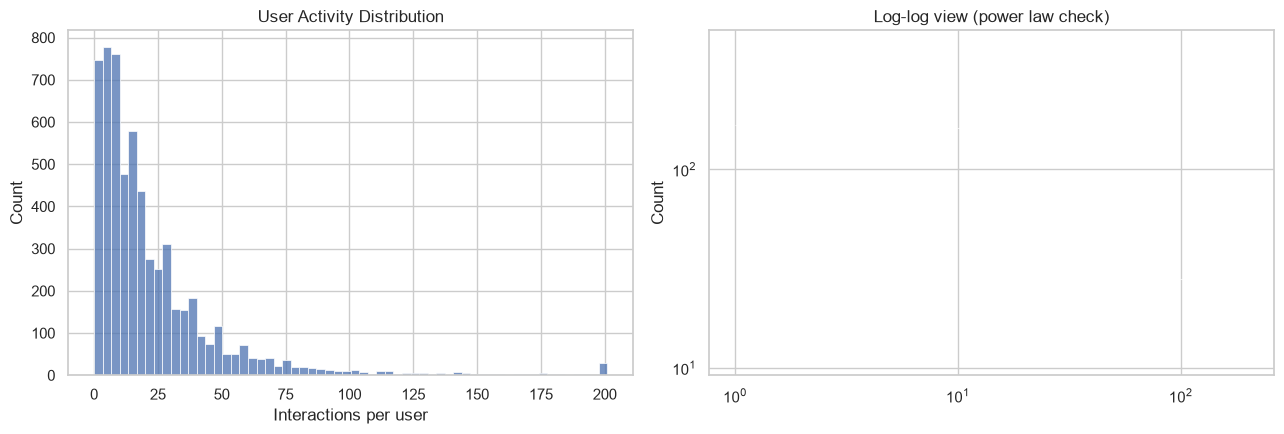

mean 23.1 | median 15 | max 201 | zero-activity 141


In [7]:
user_activity = interactions_df.groupby('user_id').size().reindex(
    users_df['user_id'], fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(user_activity, bins=60, ax=axes[0], color='#4C72B0')
axes[0].set_title('User Activity Distribution')
axes[0].set_xlabel('Interactions per user')

sns.histplot(user_activity[user_activity > 0], bins=60,
             log_scale=(True, True), ax=axes[1], color='#4C72B0')
axes[1].set_title('Log-log view (power law check)')
plt.tight_layout(); plt.show()

print('mean {:.1f} | median {:.0f} | max {:,} | zero-activity {:,}'.format(
    user_activity.mean(), user_activity.median(), user_activity.max(),
    int((user_activity == 0).sum())))

## 4. Item popularity distribution *(mandatory plot)*

Demand should be Pareto-shaped: a small head of best-sellers absorbing most of the volume, and a very long tail of items that barely sell.

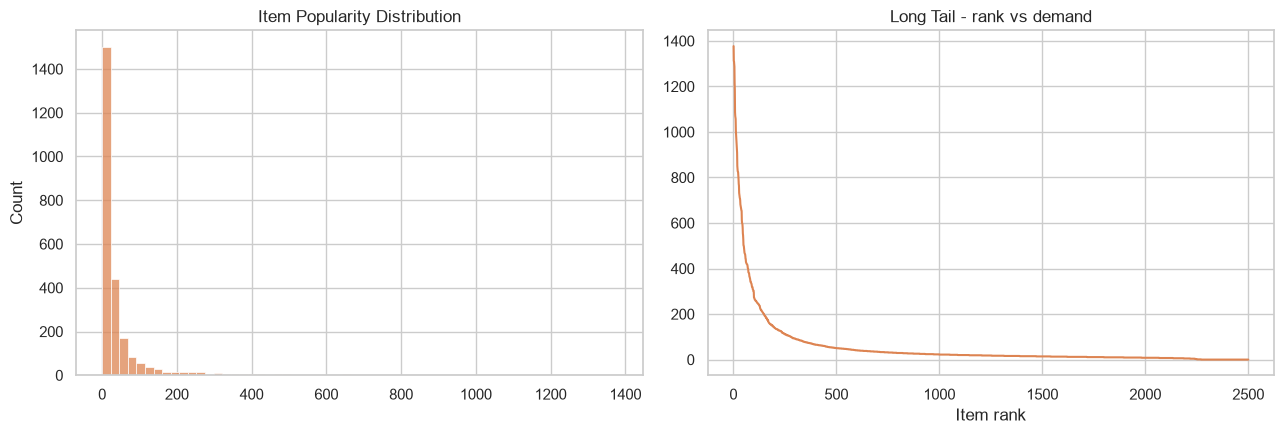

Top 10% of items hold 62.9% of all interactions


In [8]:
item_popularity = interactions_df.groupby('item_id').size().reindex(
    items_df['item_id'], fill_value=0)
sorted_pop = item_popularity.sort_values(ascending=False)

head = max(1, int(len(items_df) * 0.10))
head_share = sorted_pop.head(head).sum() / n_interactions

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(item_popularity, bins=60, ax=axes[0], color='#DD8452')
axes[0].set_title('Item Popularity Distribution')

axes[1].plot(range(1, len(sorted_pop) + 1), sorted_pop.values, color='#DD8452')
axes[1].set_title('Long Tail - rank vs demand')
axes[1].set_xlabel('Item rank')
plt.tight_layout(); plt.show()

print('Top 10% of items hold {:.1%} of all interactions'.format(head_share))

### Concentration: the Gini coefficient

A single number for how unequally demand is spread. Note the sort order - the Gini integral is defined on the **ascending** Lorenz curve. Computing it against the descending concentration curve returns the value sign-flipped, which is a mistake that is easy to miss because the magnitude looks right.

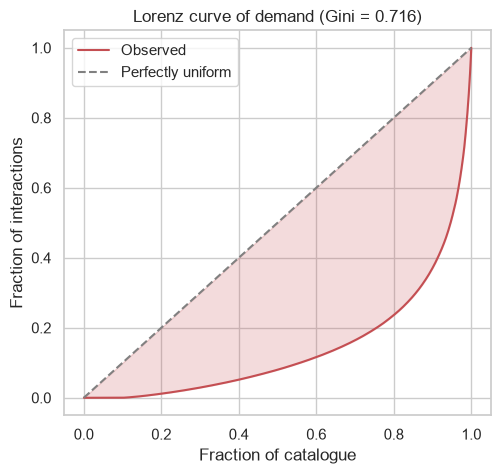

In [9]:
ascending = np.sort(item_popularity.values)
lorenz = np.cumsum(ascending) / ascending.sum()
population = np.arange(1, len(ascending) + 1) / len(ascending)
gini = 1 - 2 * np.trapezoid(lorenz, population)

plt.figure(figsize=(5.5, 5))
plt.plot(population, lorenz, color='#C44E52', label='Observed')
plt.plot([0, 1], [0, 1], '--', color='grey', label='Perfectly uniform')
plt.fill_between(population, lorenz, population, alpha=0.2, color='#C44E52')
plt.title('Lorenz curve of demand (Gini = {:.3f})'.format(gini))
plt.xlabel('Fraction of catalogue'); plt.ylabel('Fraction of interactions')
plt.legend(); plt.show()

## 5. Interaction matrix sparsity *(mandatory plot)*

Sampling at random from a 99% empty matrix renders an empty rectangle and shows nothing. Sampling the densest corner - most active users against most popular items - is the only way to see the structure.

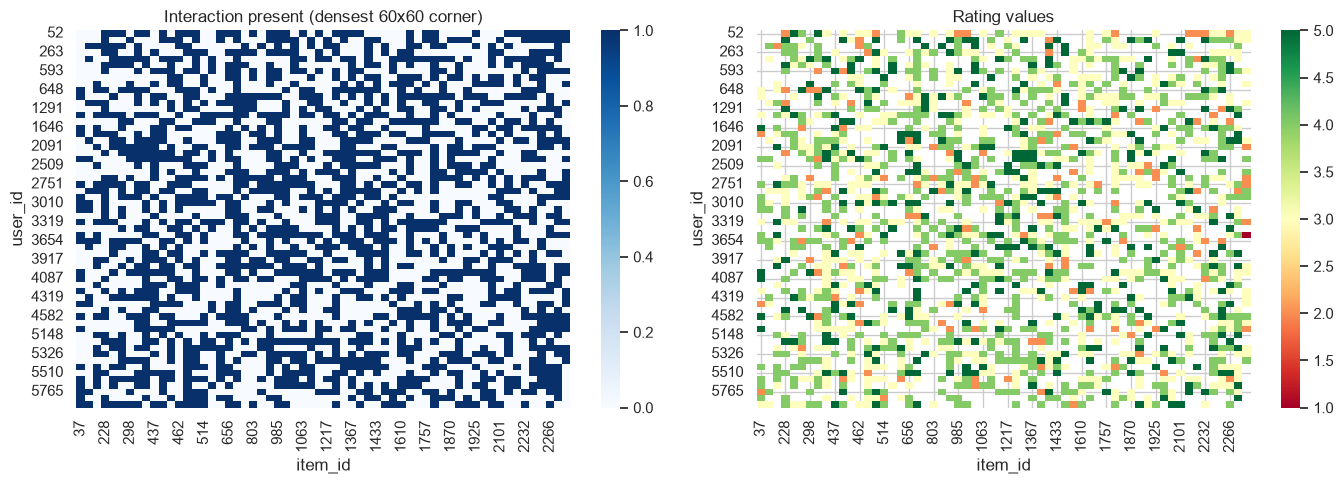

Density even in this corner: 48.0%


In [10]:
top_users = user_activity.nlargest(60).index
top_items = item_popularity.nlargest(60).index

sample = interactions_df[
    interactions_df['user_id'].isin(top_users)
    & interactions_df['item_id'].isin(top_items)]

matrix = sample.pivot_table(index='user_id', columns='item_id',
                            values='rating', aggfunc='mean')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(matrix.notna(), cmap='Blues', ax=axes[0])
axes[0].set_title('Interaction present (densest 60x60 corner)')
sns.heatmap(matrix, cmap='RdYlGn', vmin=1, vmax=5, ax=axes[1])
axes[1].set_title('Rating values')
plt.tight_layout(); plt.show()

print('Density even in this corner: {:.1%}'.format(matrix.notna().to_numpy().mean()))

## 6. Cold start

Deliberately engineered so the fallback logic is testable. A dataset where every user and item has ample history cannot demonstrate cold-start handling at all.

Users with < 3 interactions : 480 (8.0%)
Items with < 3 interactions : 255 (10.2%)


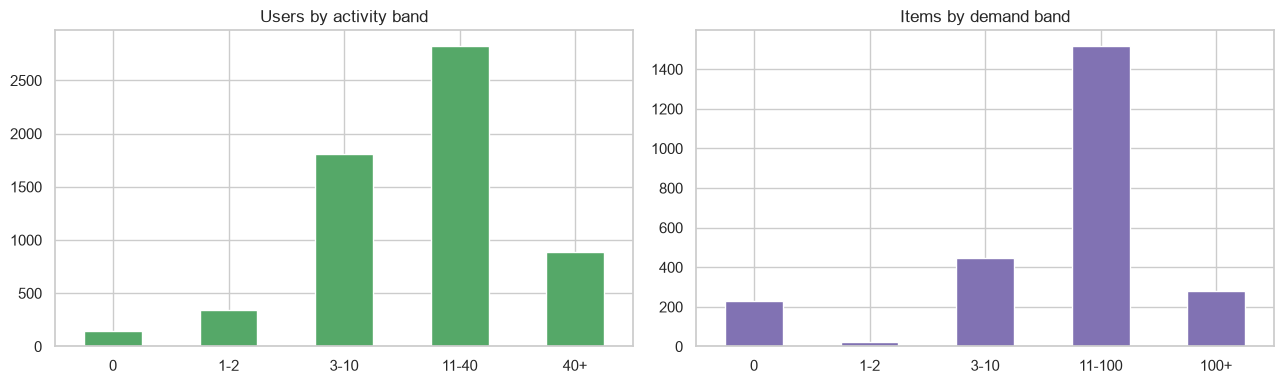

In [11]:
cold_users = int((user_activity < 3).sum())
cold_items = int((item_popularity < 3).sum())

print('Users with < 3 interactions : {:,} ({:.1%})'.format(
    cold_users, cold_users / n_users))
print('Items with < 3 interactions : {:,} ({:.1%})'.format(
    cold_items, cold_items / n_items))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pd.cut(user_activity, [-1, 0, 2, 10, 40, 1e9],
       labels=['0', '1-2', '3-10', '11-40', '40+']
       ).value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#55A868')
axes[0].set_title('Users by activity band'); axes[0].tick_params(axis='x', rotation=0)
pd.cut(item_popularity, [-1, 0, 2, 10, 100, 1e9],
       labels=['0', '1-2', '3-10', '11-100', '100+']
       ).value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#8172B3')
axes[1].set_title('Items by demand band'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

## 7. The engagement funnel

Every row is at minimum a click. From there it may progress to cart and to purchase, and may or may not receive a star rating - which is how commerce data actually arrives.

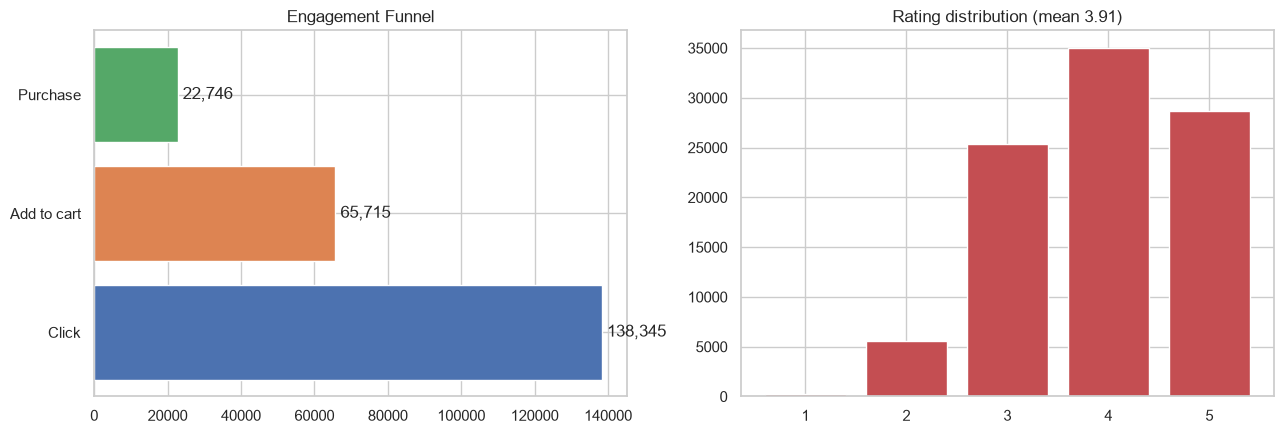

Cart rate     : 47.5% of clicks
Purchase rate : 16.4% of clicks
Revenue       : INR 133,757,218


In [12]:
clicks = int(interactions_df['click'].sum())
carts = int(interactions_df['add_to_cart'].sum())
purchases = int(interactions_df['purchase'].sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(['Click', 'Add to cart', 'Purchase'], [clicks, carts, purchases],
             color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Engagement Funnel')
for i, v in enumerate([clicks, carts, purchases]):
    axes[0].text(v, i, ' {:,}'.format(v), va='center')

rating_counts = interactions_df['rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index.astype(int), rating_counts.values, color='#C44E52')
axes[1].set_title('Rating distribution (mean {:.2f})'.format(
    interactions_df['rating'].mean()))
plt.tight_layout(); plt.show()

print('Cart rate     : {:.1%} of clicks'.format(carts / clicks))
print('Purchase rate : {:.1%} of clicks'.format(purchases / clicks))
print('Revenue       : INR {:,.0f}'.format(interactions_df['revenue'].sum()))

**A note on calibration.** Real e-commerce converts at roughly 2-3% of sessions, not 16%. The rate here is deliberately higher: at a realistic 3%, a 138k interaction log yields only ~4,000 purchases across 6,000 customers, which is far too sparse to train or evaluate a recommender on. This is a documented trade-off between behavioural realism and having enough signal to model, not an oversight - see `reports/data_risk_assessment.md`.

## 8. Latent structure - what the models must recover

The generator embedded two genuine latent factors: category affinity and segment-driven price sensitivity. These are the signals the models are supposed to find, so it matters that they are actually present.

In [13]:
purchases_df = (interactions_df[interactions_df['purchase'] == 1]
    .merge(items_df[['item_id', 'price', 'category']], on='item_id')
    .merge(users_df[['user_id', 'user_segment', 'preferred_category']], on='user_id'))

segment_price = purchases_df.groupby('user_segment')['price'].median().sort_values()
print('Median purchase price by segment:')
for segment, price in segment_price.items():
    print('  {:<20} INR {:>9,.0f}'.format(segment, price))

match = (purchases_df['category'] == purchases_df['preferred_category']).mean()
print('\nPurchases inside declared category: {:.1%}'.format(match))
print('(random would be ~10% across 10 categories)')

Median purchase price by segment:
  Budget Shopper       INR       572
  Value Seeker         INR       827
  Mainstream Buyer     INR     1,395
  Premium Buyer        INR     2,724
  Luxury Enthusiast    INR     3,361

Purchases inside declared category: 60.7%
(random would be ~10% across 10 categories)


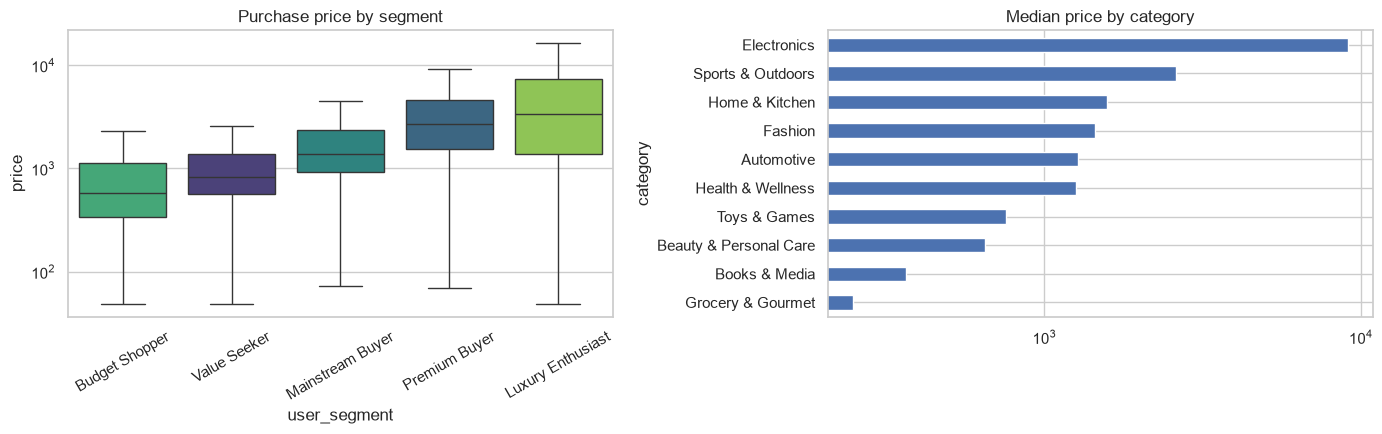

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.boxplot(data=purchases_df, x='user_segment', y='price',
            order=segment_price.index.tolist(), showfliers=False,
            hue='user_segment', legend=False, palette='viridis', ax=axes[0])
axes[0].set_yscale('log'); axes[0].tick_params(axis='x', rotation=30)
axes[0].set_title('Purchase price by segment')

items_df.groupby('category')['price'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='#4C72B0')
axes[1].set_xscale('log'); axes[1].set_title('Median price by category')
plt.tight_layout(); plt.show()

## 9. Temporal coverage

Activity is deliberately weighted toward recent months, which is what makes holding out the final 90 days a meaningful test rather than an arbitrary cut.

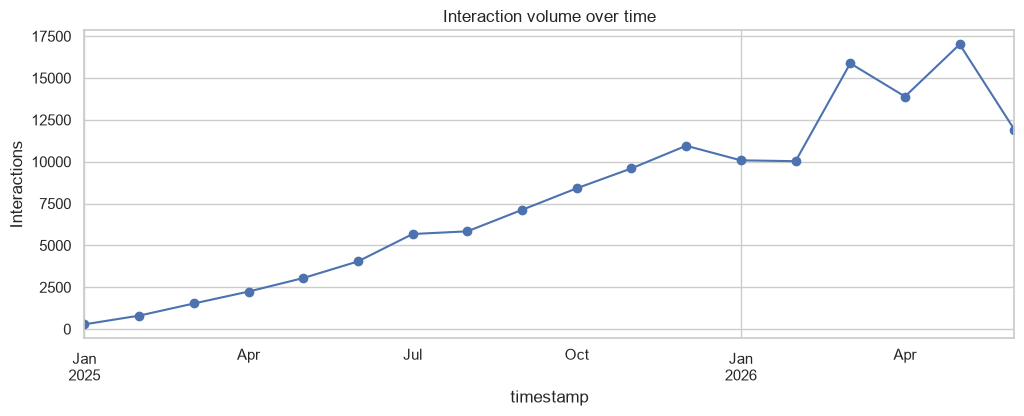

Last 90 days hold 30.1% of all interactions
This window is the held-out test period.


In [15]:
monthly = interactions_df.set_index('timestamp').resample('ME').size()
plt.figure(figsize=(12, 4))
monthly.plot(color='#4C72B0', marker='o')
plt.title('Interaction volume over time'); plt.ylabel('Interactions')
plt.show()

cutoff = interactions_df['timestamp'].max() - pd.Timedelta(days=90)
test_share = (interactions_df['timestamp'] > cutoff).mean()
print('Last 90 days hold {:.1%} of all interactions'.format(test_share))
print('This window is the held-out test period.')

## Conclusion

The dataset exhibits every property the business case requires:

| Property | Observed |
|---|---|
| Sparsity | 99.08% |
| Popularity bias | top 10% of items hold 62.9% of demand |
| Long tail | Gini 0.716 |
| Cold-start users | 480 (8.0%) |
| Cold-start items | 255 (10.2%) |
| Category preference | 60.7% of purchases in declared category |
| Price sensitivity | INR 572 (Budget) to INR 3,361 (Luxury) |

The models therefore have real structure to recover, and the evaluation that follows measures something meaningful.